# For Model Validation (Or Testing)

## Individual Testing


Initializing ShardStreamIterableDataset...
--> Scanning shards for metadata...


Scanning Shards: 100%|██████████| 150/150 [00:00<00:00, 985.63it/s]

Size of all shards combined: 0.6673 GB
--> MODE: No stats provided. Yielding RAW, UNNORMALIZED labels.
Dataset initialized with 76354 events.

  Experiment : atczaomh
  Notes      : Went back to 0.0001 wdecay and dpout 0.2, testingout new RadiusAwareHuberLoss with preset R_cutoff value.
  Model    : RNO_four_residual_merge | hidden_units=32 | temporal_res=256
  Manifest : /data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/manifest_builder/manifests/manifest_3albums_500comp.json
  Training : lr=0.001 | wd=0.0001 | min_hits=1

--- Starting Evaluation Pipeline ---
Executing evaluation on: cuda:1
Loading evaluation dataset from: <utils_dir.dataset.ShardStreamIterableDataset object at 0x7fe34cd37e80>
Dataset loaded. Total batches to evaluate: 150
Loading weights from: checkpoint_min_e32.pth...


Checkpoint successfully loaded into model on cuda:1!
Trained unnormalized statistics (Loaded from Buffer):
  X = 2.9969 ± 1337.9773
  Y = 15.6175 ± 1338.9883
  Z = -782.9150 ± 419.2670
Starting forward passes...


Evaluating: 100%|██████████| 150/150 [00:30<00:00,  4.88batch/s]


Inference complete. Formatting output arrays...
Converting Cartesian coordinates (X, Y, Z) to Spherical (R, Theta, Phi)...
--- Evaluation Finished! ---
Shape of True array: (76354, 3)
Shape of Reco array: (76354, 3)
--- Relative Radius (R) Error Statistics ---
Mean Error:   -0.1776 (-17.76%)
Median Error: -0.2090 (-20.90%)
Spread (Std): 0.3861 (38.61%)
--------------------------------------------
Sigma 68%:    0.3261 (32.61%)
68% Interval: [-0.5206, +0.1315]


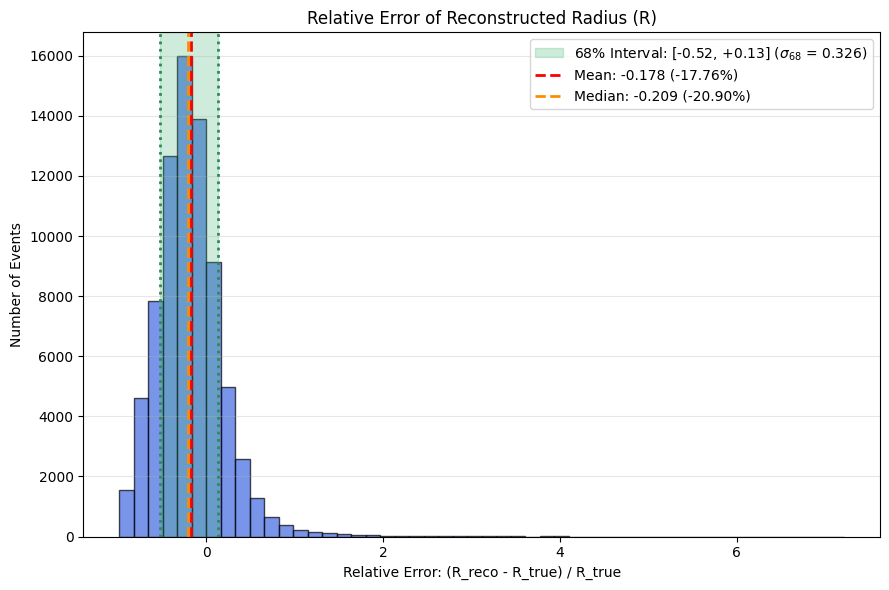

--- 3D Euclidean Distance Error (meters) ---
Mode:              588.1 m  (most common error)
Median:            914.5 m
Mean:              1056.9 m
Std:               660.7 m
--------------------------------------------
68% containment:   1229.3 m  (68% of events within this distance)


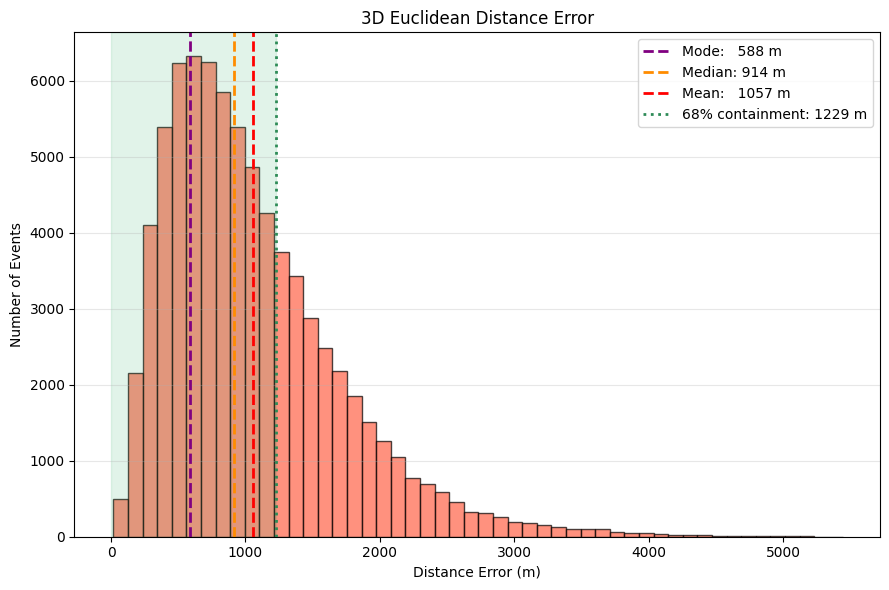

No experiment name provided — using: atczaomh

  Experiment : atczaomh
  Notes      : Went back to 0.0001 wdecay and dpout 0.2, testingout new RadiusAwareHuberLoss with preset R_cutoff value.
  Epoch      : 32
  rel_R    median=-0.2090  68%: [-0.5206, +0.1315]  σ68=0.3261
  dist     mode=588.1m  median=914.5m  68% containment=1229.3m
  Saved to : /data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/eval_log.json



In [3]:
from utils_dir import eval_utils

# ====================================================================
# CONFIG — only this changes between runs
# ====================================================================
CHECKPOINT_DIR = '/data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/model_experiments/model_RNO4_thesis/experiments/atczaomh/checkpoints'
BATCH_SIZE     = 512
LOG_PATH       = '/data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/eval_log.json'
# ====================================================================

# Automatically resolves model class, hyperparameters, and val dataset
# from the checkpoint's saved model_config — no manual specification needed
evaluator = eval_utils.ModelEvaluator.from_checkpoint(
    checkpoint_path = CHECKPOINT_DIR,
    batch_size      = BATCH_SIZE,
    spherical       = True, # SHOULD ALWAYS BE TRUE!
    device          = 'cuda:1'
)

rel_R = evaluator.show_rel_R(hist=True)
dist  = evaluator.show_euclidean_distance(hist=True)

# Append results to the shared log — overwrites if this experiment already exists
evaluator.save_to_log(
    log_path        = LOG_PATH
)

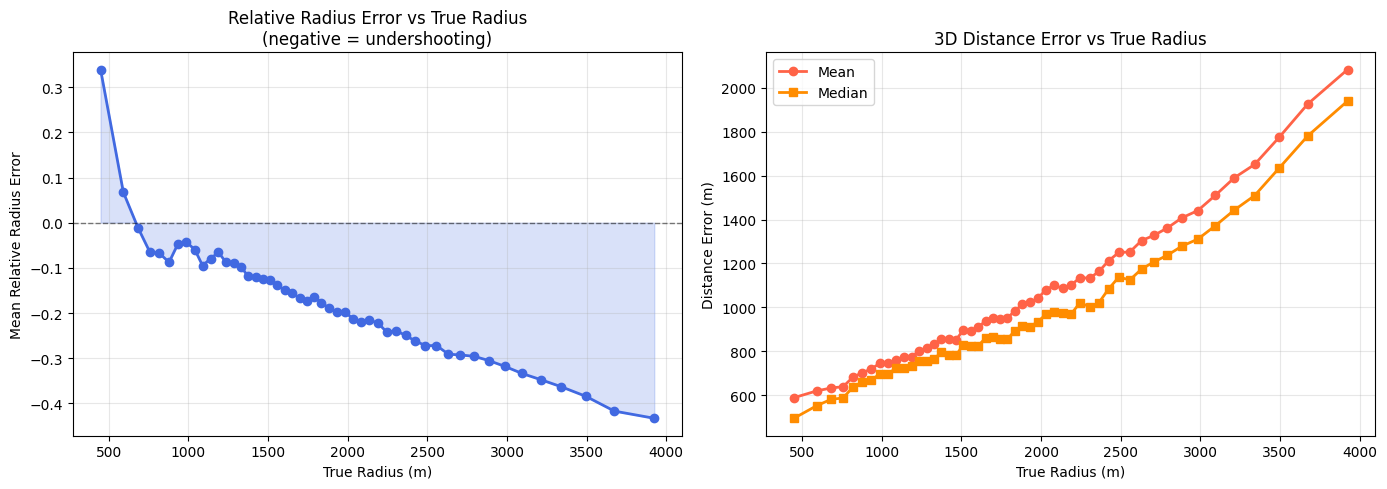


True R bin (m)         Mean rel_R   Mean dist (m)  Median dist (m)
-----------------------------------------------------------------
448                       +0.3390           588.6            495.0
591                       +0.0674           619.7            552.2
683                       -0.0108           633.0            581.5
757                       -0.0647           638.9            587.4
818                       -0.0678           681.6            636.5
878                       -0.0877           703.0            660.2
932                       -0.0479           718.8            669.0
986                       -0.0426           744.8            695.3
1040                      -0.0598           746.9            697.8
1089                      -0.0950           758.2            723.0
1139                      -0.0796           772.6            724.5
1188                      -0.0656           776.2            731.1
1236                      -0.0879           802.1            7

In [4]:
# evaluator.show_rel_R(hist=True)
# evaluator.show_euclidean_distance(hist=True)
evaluator.show_error_vs_radius(n_bins=50)

In [5]:
# Run this once in your notebook
import torch
import numpy as np

# You already have these from the evaluator
# true_arr is in spherical (R, theta, phi) — R is in physical meters
# We need normalized Cartesian radius

# Convert true spherical back to physical Cartesian
true_cart = np.array([evaluator.spher_2_cart(*r) for r in evaluator.true_arr])

# Normalize using model's label stats
label_mean = evaluator.model.label_mean.cpu().numpy()
label_std  = evaluator.model.label_std.cpu().numpy()

true_cart_norm = (true_cart - label_mean) / (label_std + 1e-8)

# Compute normalized radius for each event
true_R_norm = np.sqrt((true_cart_norm**2).sum(axis=1))

# Find what normalized radius corresponds to physical 750m
# by finding events near 750m physical and checking their normalized R
true_R_physical = evaluator.true_arr[:, 0]  # physical radius from spherical

mask_near_crossover = np.abs(true_R_physical - 750) < 50  # events within 50m of crossover
crossover_R_norm = float(np.median(true_R_norm[mask_near_crossover]))

print(f"Physical crossover: 750m")
print(f"Normalized crossover_R: {crossover_R_norm:.4f}")

Physical crossover: 750m
Normalized crossover_R: 1.0475


## Batch Evaluation

In [1]:
from utils_dir import eval_utils

# ====================================================================
# CONFIG — only this changes between runs
# ====================================================================
EXPERIMENTS_DIR = '/data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/model_experiments/model_RNO4_thesis/experiments'
BATCH_SIZE     = 512
LOG_PATH       = '/data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/batch_eval_log.json'
# ====================================================================

experiments_dict = eval_utils.get_experiment_checkpoints(EXPERIMENTS_DIR)
num_experiments = len(experiments_dict)

print(f'Found {num_experiments}, beginning evaluation:')

for idx, (experiment_name, experiment_checkpoint) in enumerate(experiments_dict.items()):
    try:
        # Automatically resolves model class, hyperparameters, and val dataset
        # from the checkpoint's saved model_config — no manual specification needed
        print('='*80)
        print(f'({idx}/{num_experiments}) EVALUTAING CHECKPOINT FROM {experiment_name}')
        print('='*80)
        evaluator = eval_utils.ModelEvaluator.from_checkpoint(
            checkpoint_path = experiment_checkpoint,
            batch_size      = BATCH_SIZE,
            spherical       = True, # SHOULD ALWAYS BE TRUE!
            device          = 'cuda:1'
        )

        # Append results to the shared log — overwrites if this experiment already exists
        evaluator.save_to_log(
            experiment_name = experiment_name,  # WandB run ID or any descriptive name
            log_path        = LOG_PATH
        )
        print('='*80)
    except (FileNotFoundError, ValueError) as e:
        print("Skipping", {experiment_name}, ':', {e})

Found 25, beginning evaluation:
(0/25) EVALUTAING CHECKPOINT FROM exp_RNO_four_mixing_wdcay-0.0e+00_hiddenu-64_lr-1.00e-03_leak-0.1_tempRes-0_dpout-0.0_5000_shards
Skipping {'exp_RNO_four_mixing_wdcay-0.0e+00_hiddenu-64_lr-1.00e-03_leak-0.1_tempRes-0_dpout-0.0_5000_shards'} : {ValueError('Checkpoint checkpoint_e9.pth has no model_config — it was saved before this feature was added. Use the standard ModelEvaluator constructor instead.')}
(1/25) EVALUTAING CHECKPOINT FROM exp_RNO_four_mixing_wdcay-0.0e+00_hiddenu-64_lr-1.00e-03_leak-0.1_tempRes-0_dpout-0.0_500_shards_chunked


/data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/utils_dir/eval_utils.py:487: UserWarning: No 'min_e' checkpoint found in /data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/model_experiments/model_RNO4_thesis/experiments/exp_RNO_four_mixing_wdcay-0.0e+00_hiddenu-64_lr-1.00e-03_leak-0.1_tempRes-0_dpout-0.0_5000_shards/checkpoints. Falling back to the latest checkpoint.
  warnings.warn(f"No 'min_e' checkpoint found in {checkpoint_path}. Falling back to the latest checkpoint.")
/data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/utils_dir/eval_utils.py:487: UserWarning: No 'min_e' checkpoint found in /data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/model_experiments/model_RNO4_thesis/experiments/exp_RNO_four_mixing_wdcay-0.0e+00_hiddenu-64_lr-1.00e-03_leak-0.1_tempRes-0_dpout-0.0_500_shards_chunked/checkpoints. Falling back to the latest checkpoint.
  warnings.war

Skipping {'exp_RNO_four_mixing_wdcay-0.0e+00_hiddenu-64_lr-1.00e-03_leak-0.1_tempRes-0_dpout-0.0_500_shards_chunked'} : {ValueError('Checkpoint checkpoint_emin_1.pth has no model_config — it was saved before this feature was added. Use the standard ModelEvaluator constructor instead.')}
(2/25) EVALUTAING CHECKPOINT FROM exp_RNO_four_mixing_wdcay-0.0e+00_hiddenu-64_lr-1.00e-03_leak-0.1_tempRes-0_dpout-0.0_5000_shards_unchunk
Skipping {'exp_RNO_four_mixing_wdcay-0.0e+00_hiddenu-64_lr-1.00e-03_leak-0.1_tempRes-0_dpout-0.0_5000_shards_unchunk'} : {ValueError('Checkpoint checkpoint_e22.pth has no model_config — it was saved before this feature was added. Use the standard ModelEvaluator constructor instead.')}
(3/25) EVALUTAING CHECKPOINT FROM exp_RNO_four_mixing_wdcay-0.0e+00_hiddenu-64_lr-1.00e-03_leak-0.1_tempRes-0_dpout-0.0_500_shards_chunked_take2


/data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/utils_dir/eval_utils.py:487: UserWarning: No 'min_e' checkpoint found in /data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/model_experiments/model_RNO4_thesis/experiments/exp_RNO_four_mixing_wdcay-0.0e+00_hiddenu-64_lr-1.00e-03_leak-0.1_tempRes-0_dpout-0.0_5000_shards_unchunk/checkpoints. Falling back to the latest checkpoint.
  warnings.warn(f"No 'min_e' checkpoint found in {checkpoint_path}. Falling back to the latest checkpoint.")
/data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/utils_dir/eval_utils.py:487: UserWarning: No 'min_e' checkpoint found in /data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/model_experiments/model_RNO4_thesis/experiments/exp_RNO_four_mixing_wdcay-0.0e+00_hiddenu-64_lr-1.00e-03_leak-0.1_tempRes-0_dpout-0.0_500_shards_chunked_take2/checkpoints. Falling back to the latest checkpoint.


Skipping {'exp_RNO_four_mixing_wdcay-0.0e+00_hiddenu-64_lr-1.00e-03_leak-0.1_tempRes-0_dpout-0.0_500_shards_chunked_take2'} : {ValueError('Checkpoint checkpoint_e10.pth has no model_config — it was saved before this feature was added. Use the standard ModelEvaluator constructor instead.')}
(4/25) EVALUTAING CHECKPOINT FROM exp_RNO_four_mixing_wdcay-0.0e+00_hiddenu-64_lr-1.00e-03_leak-0.1_tempRes-0_dpout-0.0_unchunked500_testing
Skipping {'exp_RNO_four_mixing_wdcay-0.0e+00_hiddenu-64_lr-1.00e-03_leak-0.1_tempRes-0_dpout-0.0_unchunked500_testing'} : {ValueError('Checkpoint checkpoint_e11.pth has no model_config — it was saved before this feature was added. Use the standard ModelEvaluator constructor instead.')}
(5/25) EVALUTAING CHECKPOINT FROM exp_RNO_four_mixing_wdcay-0.0e+00_hiddenu-64_lr-1.00e-03_leak-0.1_tempRes-0_dpout-0.0_compressed500_testing


...

Scanning Shards: 100%|██████████| 150/150 [00:00<00:00, 2583.18it/s]

Size of all shards combined: 0.6673 GB
--> MODE: No stats provided. Yielding RAW, UNNORMALIZED labels.
Dataset initialized with 76354 events.
Loaded config from checkpoint:
  Model    : RNO_four_residual_merge | hidden_units=32 | temporal_res=256
  Manifest : /data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/manifest_builder/manifests/manifest_3albums_500comp.json
  Training : lr=0.001 | wd=0.0001 | min_hits=1
--- Starting Evaluation Pipeline ---
Executing evaluation on: cuda:1
Loading evaluation dataset from: <utils_dir.dataset.ShardStreamIterableDataset object at 0x7f816fcc7bb0>
Dataset loaded. Total batches to evaluate: 150
Loading weights from: checkpoint_min_e16.pth...


Checkpoint successfully loaded into model on cuda:1!
Trained unnormalized statistics (Loaded from Buffer):
  X = 2.9969 ± 1337.9773
  Y = 15.6175 ± 1338.9883
  Z = -782.9150 ± 419.2670
Starting forward passes...


Evaluating: 100%|██████████| 150/150 [00:30<00:00,  4.91it/s]


Inference complete. Formatting output arrays...
Converting Cartesian coordinates (X, Y, Z) to Spherical (R, Theta, Phi)...
--- Evaluation Finished! ---
Shape of True array: (76354, 3)
Shape of Reco array: (76354, 3)
Saved to /data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/batch_eval_log.json
  rel_R    68%: [-0.4616, +0.0086]  σ68=0.2351
  dist     mode=277.6m  68% containment=912.4m
  epoch    16
